# Droplet analysis — mfx102101026

Visualizes the sparse droplet data produced by the smalldata pipeline for
`epix100_0`. Droplet finding was configured in `mfx_lute_cmpars.yaml` with:

```
threshold / thresholdLow : 5 σ above RMS noise
thresADU                 : 60 ADU  (rejects noise clusters)
useRms                   : true
nData                    : 100 000 (sparse array width per event)
```

The pipeline stores per-event sparse arrays:

| HDF5 key | Shape | Content |
|---|---|---|
| `epix100_0/droplet_nDroplets` | (nshots,) | hits per shot after ADU cut |
| `epix100_0/droplet_nDroplets_all` | (nshots,) | hits per shot before ADU cut |
| `epix100_0/droplet_sparse_data` | (nshots, 100000) | ADU per hit pixel (zero-padded) |
| `epix100_0/droplet_sparse_row` | (nshots, 100000) | row coordinate (zero-padded) |
| `epix100_0/droplet_sparse_col` | (nshots, 100000) | col coordinate (zero-padded) |
| `epix100_0/droplet_sparse_npix` | (nshots, 100000) | pixels per droplet (zero-padded) |

> **Note:** coordinates are in the **raw HDF5 frame** `(704 rows, 768 cols)`,
> not the transposed pipeline frame. The hit-map cell transposes before plotting
> to match the XES notebook convention.

Change `RUN` to analyse a different run.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

EXP   = 'mfx102101026'
RUN   = 9
SMD_DIR = f'/sdf/data/lcls/ds/mfx/{EXP}/hdf5/smalldata'
SMD_FILE = f'{SMD_DIR}/{EXP}_Run{RUN:04d}.h5'

DET   = 'epix100_0'
NDATA = 100_000     # sparse array width (matches nData in YAML)

# --- ROI on the RAW HDF5 frame (rows, cols) = (704, 768) --------------------
# IMPORTANT: droplet finding ran on the RAW detector frame, so droplet_sparse_row
# / _col are RAW coordinates and are NOT transposed (unlike the XES pipeline,
# which transposes to (768, 704) before applying its ROIs). Keep everything here
# in raw coordinates.
#
# For run 9 the emission line sits at:
#   raw ROW 149-300  → DISPERSION axis (spectral spread along the line)
#   raw COL 205-212  → CROSS-DISPERSION axis (narrow band position)
# Widen if you change the spectrometer ROI.
ROI_ROW = (140, 320)   # raw-frame rows = dispersion spread
ROI_COL = (195, 225)   # raw-frame cols = cross-dispersion band

# Load all per-shot metadata and droplet scalars at once (small)
with h5py.File(SMD_FILE, 'r') as fh:
    xray   = fh['lightStatus/xray'][:].astype(bool)
    laser  = fh['lightStatus/laser'][:].astype(bool)
    ipm    = fh.get('MfxDg2BmMon/totalIntensityJoules', np.full(xray.shape, np.nan))[:]
    n_drops     = fh[f'{DET}/droplet_nDroplets'][:]
    n_drops_all = fh[f'{DET}/droplet_nDroplets_all'][:]

n_total  = len(xray)
n_xray   = xray.sum()
xray_idx = np.where(xray)[0]

print(f'Run {RUN}: {n_total} shots total, {n_xray} xray-on')
print(f'nDroplets (xray shots): mean={n_drops[xray].mean():.1f}, '
      f'median={np.median(n_drops[xray]):.0f}, '
      f'max={n_drops[xray].max()}')

Run 9: 36021 shots total, 33020 xray-on
nDroplets (xray shots): mean=0.1, median=0, max=4


## 0. Extract droplets inside the ROI (once)

This is the only cell that touches the big sparse arrays. It streams the file
in **contiguous** slabs (fast h5py reads, no fancy indexing over 36 k shots),
keeps only droplets that are (a) real (`data > 0`), (b) on an xray shot, and
(c) **inside `ROI_ROW × ROI_COL`**, and stores compact flat arrays in memory.
Every plot below reuses these — nothing re-reads the HDF5, so the notebook
cannot hang on a giant read.

In [2]:
CHUNK = 4000       # shots per slab (contiguous read)
MAX_DROPLETS = 600 # only read the first N sparse columns.
                   # Real droplets are packed at low column indices (nDroplets_all
                   # max ≈ 512 here); the array is 100000 wide but the rest is
                   # zero-padding. Reading only these columns is ~150× faster.

xray_bool = xray  # per-shot mask aligned to file order
flat_row, flat_col, flat_data, flat_shot = [], [], [], []

with h5py.File(SMD_FILE, 'r') as fh:
    d_row  = fh[f'{DET}/droplet_sparse_row']
    d_col  = fh[f'{DET}/droplet_sparse_col']
    d_data = fh[f'{DET}/droplet_sparse_data']
    n_shots = d_data.shape[0]
    ncol = min(MAX_DROPLETS, d_data.shape[1])
    for s0 in range(0, n_shots, CHUNK):
        s1 = min(s0 + CHUNK, n_shots)
        # contiguous slab, only first ncol columns (fast, tiny read)
        da = d_data[s0:s1, :ncol]
        r  = d_row [s0:s1, :ncol]
        c  = d_col [s0:s1, :ncol]
        xr = xray_bool[s0:s1][:, None]   # broadcast per-shot mask
        keep = (da > 0) & xr \
             & (r >= ROI_ROW[0]) & (r < ROI_ROW[1]) \
             & (c >= ROI_COL[0]) & (c < ROI_COL[1])
        if keep.any():
            shot_of = (s0 + np.arange(s1 - s0))[:, None] * np.ones(da.shape[1], dtype=int)
            flat_row.append(r[keep].astype(int))
            flat_col.append(c[keep].astype(int))
            flat_data.append(da[keep])
            flat_shot.append(shot_of[keep].astype(int))

flat_row  = np.concatenate(flat_row)  if flat_row  else np.array([], dtype=int)
flat_col  = np.concatenate(flat_col)  if flat_col  else np.array([], dtype=int)
flat_data = np.concatenate(flat_data) if flat_data else np.array([], dtype=float)
flat_shot = np.concatenate(flat_shot) if flat_shot else np.array([], dtype=int)

print(f'ROI rows {ROI_ROW}, cols {ROI_COL}')
print(f'Droplets inside ROI on xray shots: {len(flat_data)}')
if len(flat_data):
    print(f'  ADU: min {flat_data.min():.0f}, median {np.median(flat_data):.0f}, '
          f'max {flat_data.max():.0f}')
    print(f'  raw rows {flat_row.min()}–{flat_row.max()}, '
          f'cols {flat_col.min()}–{flat_col.max()}')

ROI rows (140, 320), cols (195, 225)
Droplets inside ROI on xray shots: 2306
  ADU: min 60, median 82, max 329
  raw rows 147–308, cols 205–212


## 1. Droplets per shot

Distribution and time-series of `nDroplets` (after ADU cut) and `nDroplets_all`
(before ADU cut) for xray-on shots. A stable run should show a narrow, roughly
Poisson-like distribution. The ratio `nDroplets / nDroplets_all` indicates how
many candidate clusters survive the `thresADU = 60` cut.

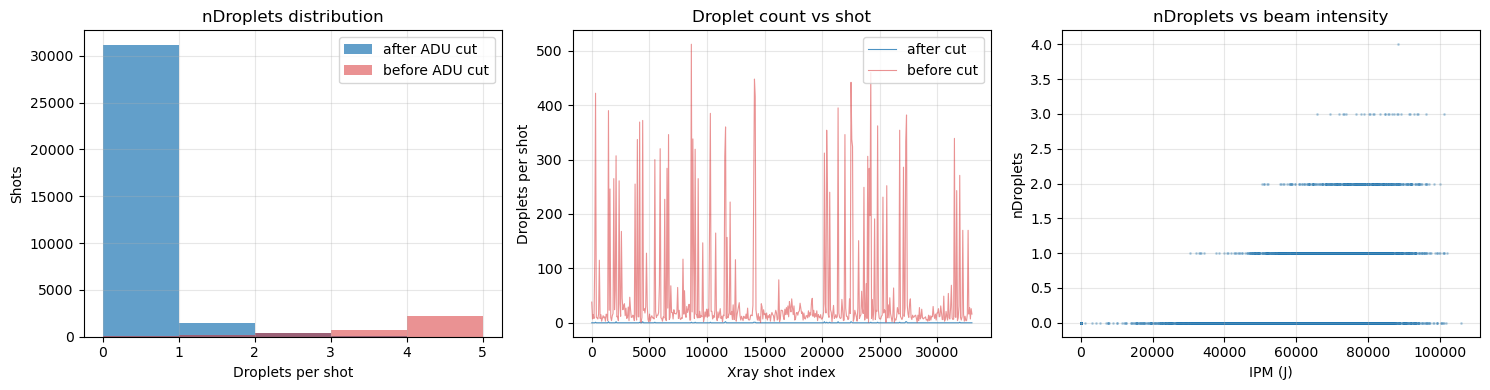

ADU-cut survival: 0.1%  (mean 0.1 / 52.2 drops/shot kept)


In [3]:
nd     = n_drops[xray]
nd_all = n_drops_all[xray]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution
ax = axes[0]
bins = np.arange(0, min(nd.max() + 2, 500))
ax.hist(nd,     bins=bins, alpha=0.7, label='after ADU cut', color='C0')
ax.hist(nd_all, bins=bins, alpha=0.5, label='before ADU cut', color='C3')
ax.set_xlabel('Droplets per shot')
ax.set_ylabel('Shots')
ax.set_title('nDroplets distribution')
ax.legend()
ax.grid(alpha=0.3)

# Time series
ax = axes[1]
shot_idx = np.arange(len(nd))
# downsample for readability
step = max(1, len(nd) // 500)
ax.plot(shot_idx[::step], nd[::step],     lw=0.8, alpha=0.8, label='after cut',  color='C0')
ax.plot(shot_idx[::step], nd_all[::step], lw=0.8, alpha=0.5, label='before cut', color='C3')
ax.set_xlabel('Xray shot index')
ax.set_ylabel('Droplets per shot')
ax.set_title('Droplet count vs shot')
ax.legend()
ax.grid(alpha=0.3)

# vs IPM
ax = axes[2]
ipm_xray = ipm[xray]
valid = np.isfinite(ipm_xray) & (ipm_xray > 0)
if valid.sum() > 10:
    ax.scatter(ipm_xray[valid], nd[valid], s=1, alpha=0.3, color='C0')
    ax.set_xlabel('IPM (J)')
    ax.set_ylabel('nDroplets')
    ax.set_title('nDroplets vs beam intensity')
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'IPM not available', ha='center', va='center',
            transform=ax.transAxes)
    ax.set_title('nDroplets vs IPM')

plt.tight_layout()
plt.show()

survival = nd.sum() / nd_all.sum() if nd_all.sum() > 0 else float('nan')
print(f'ADU-cut survival: {100*survival:.1f}%  '
      f'(mean {nd.mean():.1f} / {nd_all.mean():.1f} drops/shot kept)')

## 2. ADU spectrum (single-photon peak)

Histogram of per-droplet total ADU for all ROI droplets (from cell 0). The
single-photon peak for Fe Kα (~6.4 keV) on an ePix100 is expected near
**~100 ADU**. A clean peak confirms the `thresADU = 60` cut sits below the
photon peak.

33020 xray shots → 2306 ROI droplets (0.070 droplets/shot)
Per-droplet ADU: min=60  median=82  mean=95.0  max=329


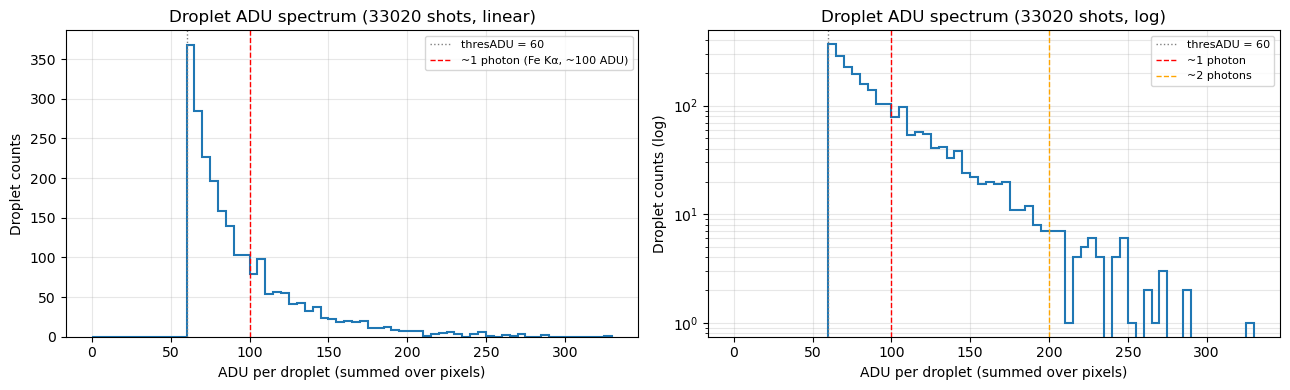

In [4]:
# Uses the ROI-filtered droplets from cell 0 (flat_data). No HDF5 re-read.
# flat_data = PER-DROPLET TOTAL ADU (≈ one photon each, ~96 ADU for Fe Kα).
flat_adu = flat_data

print(f'{n_xray} xray shots → {len(flat_adu)} ROI droplets '
      f'({len(flat_adu)/n_xray:.3f} droplets/shot)')
if len(flat_adu):
    print(f'Per-droplet ADU: min={flat_adu.min():.0f}  median={np.median(flat_adu):.0f}  '
          f'mean={flat_adu.mean():.1f}  max={flat_adu.max():.0f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Linear scale
ax = axes[0]
bins = np.arange(0, min(flat_adu.max() + 5, 600), 5)
ax.hist(flat_adu, bins=bins, color='C0', histtype='step', lw=1.5)
ax.axvline(60,  color='gray', ls=':', lw=1, label='thresADU = 60')
ax.axvline(100, color='red',  ls='--', lw=1, label='~1 photon (Fe Kα, ~100 ADU)')
ax.set_xlabel('ADU per droplet (summed over pixels)')
ax.set_ylabel('Droplet counts')
ax.set_title(f'Droplet ADU spectrum ({len(xray_idx)} shots, linear)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Log scale
ax = axes[1]
ax.hist(flat_adu, bins=bins, color='C0', histtype='step', lw=1.5)
ax.axvline(60,  color='gray', ls=':', lw=1, label='thresADU = 60')
ax.axvline(100, color='red',  ls='--', lw=1, label='~1 photon')
ax.axvline(200, color='orange', ls='--', lw=1, label='~2 photons')
ax.set_xlabel('ADU per droplet (summed over pixels)')
ax.set_ylabel('Droplet counts (log)')
ax.set_title(f'Droplet ADU spectrum ({len(xray_idx)} shots, log)')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 3. Hit map (accumulated 2D image)

Pixel-hit density accumulated over many shots. Bright regions = frequent hits
(emission lines). The map is transposed to `(768 rows, 704 cols)` to match the
XES-notebook convention. The Kα/Kβ ROI bands from `mfx102101026_static_xes.yaml`
are overlaid as dashed lines.

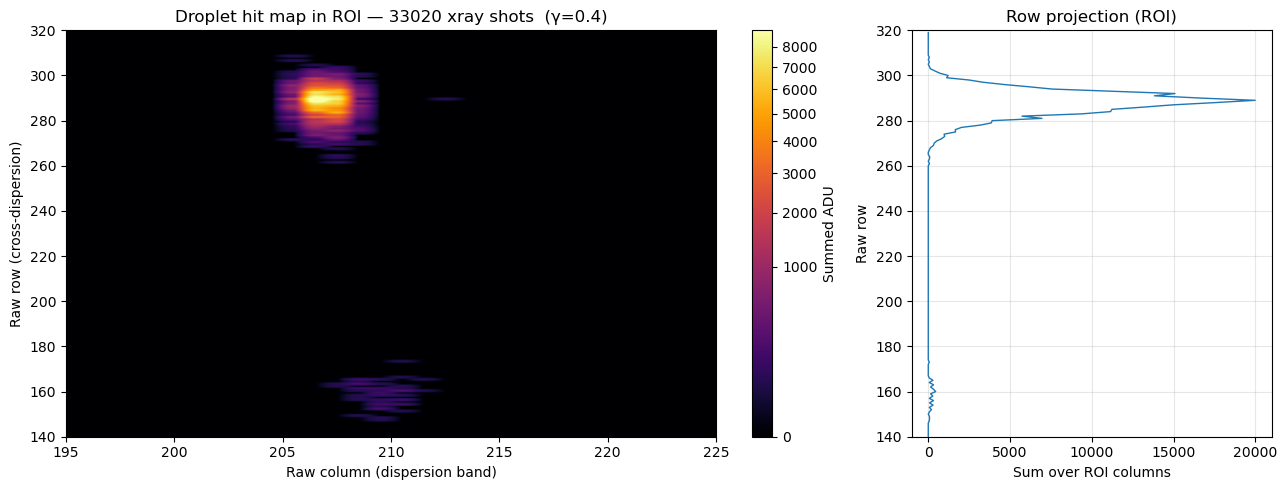

Brightest raw row in ROI: 289  (total ADU in ROI: 219112)


In [5]:
# Uses the ROI-filtered droplets from cell 0 (flat_row/col/data). No re-read.
# Accumulate a small ROI-sized image directly in raw-frame coordinates.
if len(flat_data) == 0:
    print('No droplets in ROI — nothing to map.')
else:
    r0, r1 = ROI_ROW
    c0, c1 = ROI_COL
    hit_map_roi = np.zeros((r1 - r0, c1 - c0), dtype=float)
    np.add.at(hit_map_roi, (flat_row - r0, flat_col - c0), flat_data)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                             gridspec_kw={'width_ratios': [2, 1]})

    ax = axes[0]
    vmax = np.percentile(hit_map_roi[hit_map_roi > 0], 99) if (hit_map_roi > 0).any() else 1
    im = ax.imshow(hit_map_roi, aspect='auto', origin='lower',
                   extent=[c0, c1, r0, r1],
                   norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
                   cmap='inferno')
    ax.set_xlabel('Raw column (cross-dispersion band)')
    ax.set_ylabel('Raw row (dispersion / spectral axis)')
    ax.set_title(f'Droplet hit map in ROI — {n_xray} xray shots  (γ=0.4)')
    plt.colorbar(im, ax=ax, label='Summed ADU', fraction=0.046)

    # Projection onto the dispersion (raw row) axis within the ROI
    ax = axes[1]
    row_prof = hit_map_roi.sum(axis=1)   # sum over cross-dispersion cols
    rows_axis = np.arange(r0, r1)
    ax.plot(row_prof, rows_axis, lw=1, color='C0')
    ax.set_xlabel('Sum over cross-dispersion cols')
    ax.set_ylabel('Raw row (dispersion / spectral axis)')
    ax.set_title('Dispersion projection (ROI)')
    ax.set_ylim(r0, r1)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    peak_row = rows_axis[np.argmax(row_prof)]
    print(f'Brightest raw row in ROI: {peak_row}  '
          f'(total ADU in ROI: {hit_map_roi.sum():.0f})')

## 4. Reconstructed 1D spectra from sparse data

Project the ROI droplet hits (from cell 0) onto the dispersion axis, which
runs along raw ROWS. This is a direct cross-check against the `ROI_area`-based
spectrum in `mfx102101026_static_xes_visualization.ipynb`. No HDF5 re-read.

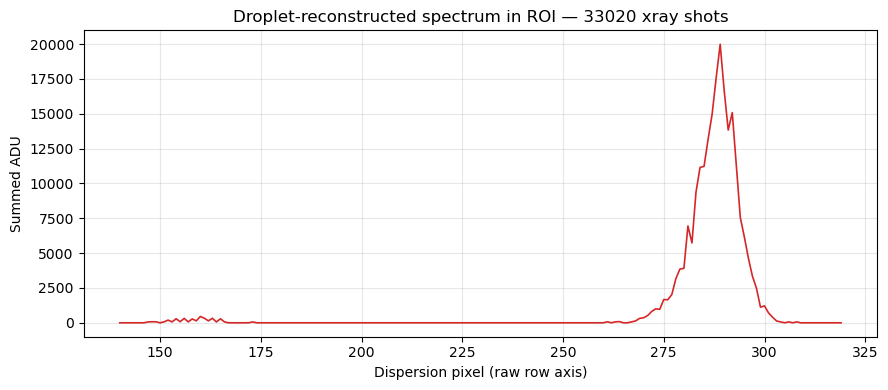

Total ADU in ROI spectrum: 219112
Peak at raw row 289


In [6]:
# Dispersion runs along raw ROWS; project the ROI droplets onto that axis.
if len(flat_data) == 0:
    print('No droplets in ROI — nothing to project.')
else:
    r0, r1 = ROI_ROW
    spec = np.bincount(flat_row - r0, weights=flat_data,
                       minlength=(r1 - r0)).astype(float)
    rows_axis = np.arange(r0, r1)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(rows_axis, spec, color='C3', lw=1.2)
    ax.set_xlabel('Dispersion pixel (raw row axis)')
    ax.set_ylabel('Summed ADU')
    ax.set_title(f'Droplet-reconstructed spectrum in ROI — {n_xray} xray shots')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Total ADU in ROI spectrum: {spec.sum():.0f}')
    print(f'Peak at raw row {rows_axis[np.argmax(spec)]}')

## 5. Hit occupancy per pixel

Fraction of xray shots in which each ROI pixel is hit at least once. Useful
for spotting hot pixels (always on) or dead pixels. Uses the ROI droplets
from cell 0 — no HDF5 re-read.

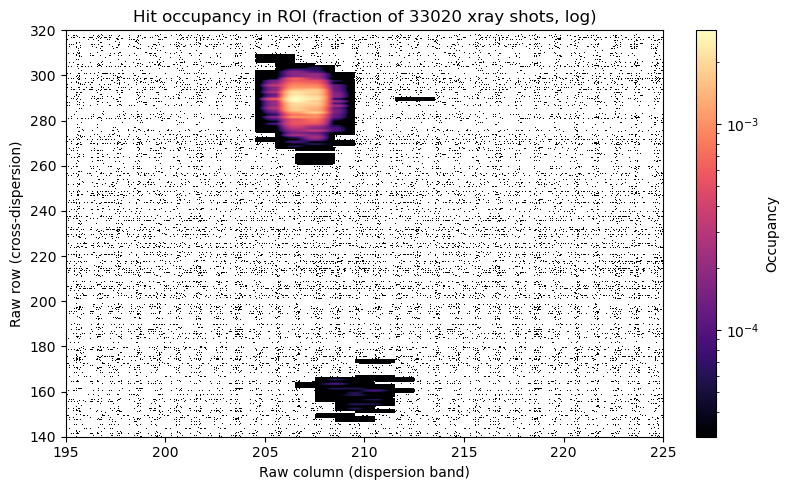

ROI pixels with occupancy > 50%: 0
Max occupancy: 0.285%


In [7]:
if len(flat_data) == 0:
    print('No droplets in ROI — nothing to map.')
else:
    r0, r1 = ROI_ROW
    c0, c1 = ROI_COL
    # Count hits per ROI pixel (presence, not ADU)
    occ_roi = np.zeros((r1 - r0, c1 - c0), dtype=float)
    np.add.at(occ_roi, (flat_row - r0, flat_col - c0), 1)
    occ_roi /= n_xray   # fraction of xray shots

    fig, ax = plt.subplots(figsize=(8, 5))
    vmin = max(occ_roi[occ_roi > 0].min(), 1e-6) if (occ_roi > 0).any() else 1e-6
    im = ax.imshow(occ_roi, aspect='auto', origin='lower',
                   extent=[c0, c1, r0, r1],
                   norm=mcolors.LogNorm(vmin=vmin, vmax=max(occ_roi.max(), vmin*10)),
                   cmap='magma')
    ax.set_xlabel('Raw column (cross-dispersion band)')
    ax.set_ylabel('Raw row (dispersion / spectral axis)')
    ax.set_title(f'Hit occupancy in ROI (fraction of {n_xray} xray shots, log)')
    plt.colorbar(im, ax=ax, label='Occupancy', fraction=0.046)
    plt.tight_layout()
    plt.show()

    hot_thresh = 0.5
    n_hot = (occ_roi > hot_thresh).sum()
    print(f'ROI pixels with occupancy > {hot_thresh*100:.0f}%: {n_hot}')
    print(f'Max occupancy: {occ_roi.max()*100:.3f}%')

## 6. (Optional) Photon-counting: estimated photons per shot

Divide each droplet's ADU by the expected single-photon ADU to estimate photon
count. For Fe Kα at 6.4 keV on ePix100: **~100 ADU/photon** (refine from the
ADU spectrum peak in Section 2). Change `ADU_PER_PHOTON` accordingly.

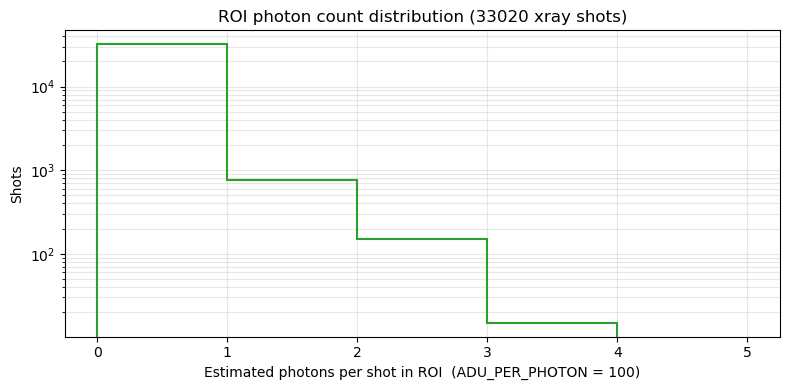

Estimated ROI photons/shot: mean=0.066, max=4, shots with ≥1 photon: 1873


In [8]:
ADU_PER_PHOTON = 100.0   # TODO: refine from Section 2 peak position

# Uses ROI droplets from cell 0 (flat_data + flat_shot). No HDF5 re-read.
# Each droplet's ADU / ADU_PER_PHOTON = photons in that droplet; sum per shot.
if len(flat_data) == 0:
    print('No droplets in ROI — nothing to count.')
else:
    photons_per_drop = flat_data / ADU_PER_PHOTON
    # Sum photons per originating shot, then keep only xray shots that had a hit
    per_shot = np.zeros(n_total)
    np.add.at(per_shot, flat_shot, photons_per_drop)
    # Distribution over xray shots (include zeros for shots with no ROI droplet)
    total_photons_per_shot = per_shot[xray]

    fig, ax = plt.subplots(figsize=(8, 4))
    hi = max(total_photons_per_shot.max() + 2, 3)
    bins = np.arange(0, min(hi, 50))
    ax.hist(total_photons_per_shot, bins=bins, color='C2', histtype='step', lw=1.5)
    ax.set_xlabel(f'Estimated photons per shot in ROI  (ADU_PER_PHOTON = {ADU_PER_PHOTON:.0f})')
    ax.set_ylabel('Shots')
    ax.set_title(f'ROI photon count distribution ({n_xray} xray shots)')
    ax.set_yscale('log')
    ax.grid(alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

    print(f'Estimated ROI photons/shot: mean={total_photons_per_shot.mean():.3f}, '
          f'max={total_photons_per_shot.max():.0f}, '
          f'shots with ≥1 photon: {(total_photons_per_shot > 0).sum()}')